In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sys
import os

sys.path.append(os.path.abspath('..'))
from ab_framework.methods.delta import DeltaMethod

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

In [ ]:
np.random.seed(42)
n_users = 20000


impressions = np.random.lognormal(mean=2, sigma=1, size=n_users).astype(int) + 1

true_ctr = 0.05
clicks = np.random.binomial(n=impressions, p=true_ctr)

print(f"Сгенерировано юзеров: {n_users:,}")
print(f"Всего показов: {impressions.sum():,}")
print(f"Всего кликов:  {clicks.sum():,}")

Сгенерировано юзеров: 20,000
Всего показов: 255,952
Всего кликов:  12,677


In [5]:

user_ctrs = clicks / impressions
naive_mean = np.mean(user_ctrs)
naive_var = np.var(user_ctrs, ddof=1) / n_users 

delta_engine = DeltaMethod()
delta_mean, delta_var = delta_engine.calculate_ratio_stats(clicks, impressions)

print("Результаты расчета метрики CTR")
print(f"Истинный бизнес-CTR (Клики/Показы): {clicks.sum() / impressions.sum():.4f}\n")

print(f"[Наивный подход]")
print(f"Оценка CTR: {naive_mean:.4f} (Искажена!)")
print(f"Дисперсия:  {naive_var:.8f}\n")

print(f"[Дельта-метод]")
print(f"Оценка CTR: {delta_mean:.4f} (Точная)")
print(f"Дисперсия:  {delta_var:.8f} (Корректная для T-теста)")

Результаты расчета метрики CTR
Истинный бизнес-CTR (Клики/Показы): 0.0495

[Наивный подход]
Оценка CTR: 0.0500 (Искажена!)
Дисперсия:  0.00000045

[Дельта-метод]
Оценка CTR: 0.0495 (Точная)
Дисперсия:  0.00000018 (Корректная для T-теста)


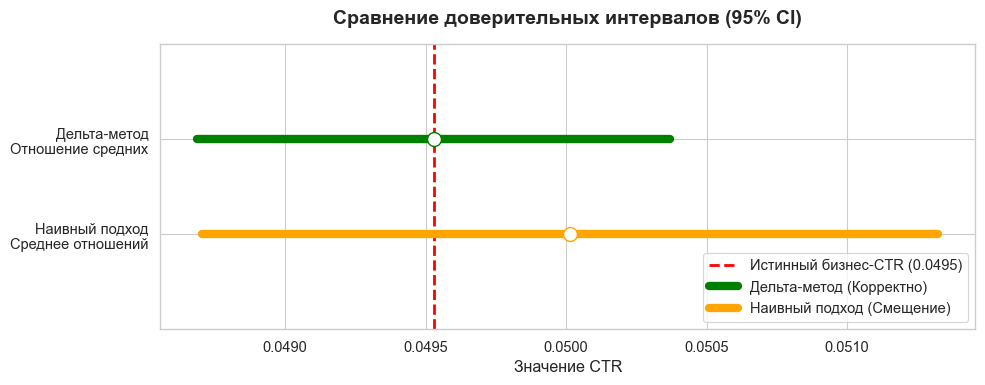

In [ ]:
z = 1.96
true_metric = clicks.sum() / impressions.sum()

ci_naive = (naive_mean - z * np.sqrt(naive_var), naive_mean + z * np.sqrt(naive_var))
ci_delta = (delta_mean - z * np.sqrt(delta_var), delta_mean + z * np.sqrt(delta_var))

plt.figure(figsize=(10, 4))

plt.axvline(true_metric, color='red', linestyle='--', linewidth=2, label=f'Истинный бизнес-CTR ({true_metric:.4f})')

plt.plot(ci_delta, [1, 1], color='green', linewidth=6, solid_capstyle='round', label='Дельта-метод (Корректно)')
plt.plot(delta_mean, 1, marker='o', markersize=10, color='white', markeredgecolor='green')

plt.plot(ci_naive, [0.5, 0.5], color='orange', linewidth=6, solid_capstyle='round', label='Наивный подход (Смещение)')
plt.plot(naive_mean, 0.5, marker='o', markersize=10, color='white', markeredgecolor='orange')

plt.title('Сравнение доверительных интервалов (95% CI)', fontsize=14, fontweight='bold', pad=15)
plt.yticks([0.5, 1], ['Наивный подход\nСреднее отношений', 'Дельта-метод\nОтношение средних'])
plt.ylim(0, 1.5)
plt.xlabel('Значение CTR')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()